# Sentence Embedding

In [5]:
! pip install sentence-transformers

### Step 1: Import

In [6]:
from sentence_transformers import SentenceTransformer

C:\Users\Suryaprakash\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 2: Load Model

In [7]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Model Loaded Successfully")

Model Loaded Successfully


### Step 3: Create Sample Sentences

In [8]:
sentences = [
    "NVIDIA develops GPUs for AI.",
    "CUDA accelerates machine learning.",
    "RTX graphics cards are used in gaming.",
    "Researchers train deep learning models."
]

### Step 4: Convert Sentences to Embeddings


In [9]:
embeddings = model.encode(sentences)

print(embeddings.shape)

(4, 384)


### Meaning:

### 4 sentences
#### 384-dimensional vector

### Step 5: Check First Embedding

In [10]:
print(embeddings[0][:10])

[-0.0525018  -0.02938656 -0.04331466  0.03369068  0.01687884 -0.06681395
 -0.05680249  0.02824275  0.01325759  0.01109202]


### Step 6: Semantic Search

In [11]:
query = "AI training"

In [12]:
query_embedding = model.encode(query)

### Step 7: Similarity Search

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(
    [query_embedding],
    embeddings
)

print(scores)

[[0.4034147  0.32380688 0.10023536 0.44591856]]


### Step 8: Best Match


In [14]:
best_index = scores.argmax()

print(sentences[best_index])

Researchers train deep learning models.


# Evolution of Text Representation

## Stage 1: TF-IDF

### Sentence

```
NVIDIA develops GPUs for AI
```

becomes:

```text
[nvidia=0.8, gpu=0.7, ai=0.9]
```

### What TF-IDF Knows

✔ Important words

### What TF-IDF Doesn't Know

**AI = Artificial Intelligence**

No idea.

**GPU = Graphics Processor**

No idea.

Every word is treated independently.

---

## Stage 2: Word2Vec

Instead of:

```text
AI = 0.9
```

we get:

```text
AI = [0.23, 0.87, -0.41, ...]
```

Words used in similar contexts get similar vectors.

### Example

#### Corpus

```text
Machine Learning uses AI
Deep Learning uses AI
```

Word2Vec learns:

```text
Machine ≈ Deep
Learning ≈ Learning
AI ≈ Intelligence
```

### Problem

Word2Vec gives vectors for **words**.

Not **sentences**.

#### Sentence

```text
NVIDIA develops GPUs
```

How do we represent the entire sentence?

Common approach:

```text
Average all word vectors
```

which loses information.

---

## Stage 3: Transformers

This changed everything.

Instead of learning words separately:

```text
Word1
Word2
Word3
```

Transformer looks at:

```text
ALL WORDS
AT ONCE
```

### Traditional Models

#### Sentence

```text
The GPU processes AI workloads
```

#### RNN

```text
The → GPU → processes → AI → workloads
```

One word at a time.

### Problem

Long-range relationships get forgotten.

---

## Transformer

### Sentence

```text
The GPU processes AI workloads
```

Transformer sees:

```text
The
GPU
processes
AI
workloads
```

simultaneously.

It asks:

> Which words are important for understanding this word?

This mechanism is called:

## Self-Attention

### Example

#### Sentence

```text
NVIDIA released Blackwell because it improves AI performance.
```

#### Question

What does **"it"** refer to?

Transformer learns:

```text
it → Blackwell
```

through attention.

### Visualized

```text
it
│
├── NVIDIA (small attention)
├── released (small)
├── Blackwell (HIGH)
└── performance (medium)
```

### Attention Formula (Conceptual)

```text
Word
 ↓
Attention Scores
 ↓
Relevant Words
 ↓
Better Understanding
```

This is why transformers understand context much better than Word2Vec.

---

# What is BERT?

BERT is a transformer.

Created by:

```text
Google
```

### Example

#### Input 1

```text
Apple sells phones.
```

#### Input 2

```text
I ate an apple.
```

### Word2Vec

```text
apple = same vector
```

Always.

### BERT

```text
apple (company)
```

gets one vector.

```text
apple (fruit)
```

gets another.

Because context changes meaning.

---

# What is Sentence Transformer?

Sentence Transformer is built on top of transformers like:

- BERT
- RoBERTa
- MiniLM
- MPNet

Instead of generating word vectors:

```text
Word
 ↓
Embedding
```

it generates:

```text
Entire Sentence
 ↓
Embedding
```

### Example

```python
model.encode(
    "NVIDIA develops GPUs"
)
```

Output:

```text
[0.123, -0.89, 0.54, ...]
```

384 numbers.

Representing the entire meaning.

---

# Why Sentence Transformers Were Created

### Problem

BERT gives embeddings for words/tokens.

Finding sentence similarity is difficult.

Sentence Transformers are trained so that:

### Similar Sentences

produce:

### Similar Vectors

#### Example

```text
NVIDIA develops GPUs.
```

```text
NVIDIA manufactures graphics processors.
```

Vectors become close together.

But:

```text
I love pizza.
```

becomes far away.

---

# What Happened in Your Semantic Search

When you wrote:

```python
query_embedding = model.encode(
    "AI training"
)
```

you created:

```text
[0.32, -0.55, 0.81, ...]
```

Each sentence in your corpus also has:

```text
[0.12, 0.45, -0.22, ...]
```

Then:

```python
cosine_similarity()
```

measures:

> How close are these vectors?

### Closest Vector

```text
Researchers train deep learning models.
```

gets returned.

---

# Complete Evolution Timeline

```text
TF-IDF
  ↓
Important Words

Word2Vec
  ↓
Word Meaning

RNN / LSTM
  ↓
Sequence Understanding

Transformers
  ↓
Context Understanding

BERT
  ↓
Contextual Word Embeddings

Sentence Transformers
  ↓
Sentence Embeddings

Semantic Search
  ↓
Find Meaning Instead of Keywords
```

## Now we completed upto embeddings , we will convert this into a RAG model

### Top K Matches

In [15]:
import numpy as np

top_indices = np.argsort(scores[0])[::-1][:5]

for idx in top_indices:
    print(sentences[idx])

Researchers train deep learning models.
NVIDIA develops GPUs for AI.
CUDA accelerates machine learning.
RTX graphics cards are used in gaming.


### Step 5: Build a Search Function


In [16]:
def semantic_search(query):

    query_embedding = model.encode(query)

    scores = cosine_similarity(
        [query_embedding],
        embeddings
    )

    best_index = scores.argmax()

    return sentences[best_index]

In [17]:
semantic_search("AI hardware")

'NVIDIA develops GPUs for AI.'

### Step 6: Interactive Search

In [18]:
while True:

    query = input("Ask: ")

    if query == "exit":
        break

    print(
        semantic_search(query)
    )

CUDA accelerates machine learning.
CUDA accelerates machine learning.
NVIDIA develops GPUs for AI.
RTX graphics cards are used in gaming.
CUDA accelerates machine learning.
CUDA accelerates machine learning.


### Step 7: Store Embeddings

In [20]:
import pickle

with open(
    r"C:\Users\Suryaprakash\OneDrive\Documents\Python\word2Vec_prj\models\nvidia_embeddings.pkl",
    "wb"
) as f:

    pickle.dump(
        embeddings,
        f
    )

### PCA Visualization

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

### reduce dimensions

In [22]:
pca = PCA(n_components=2)

reduced_embeddings = pca.fit_transform(
    embeddings
)

print(reduced_embeddings.shape)

(4, 2)


### Plot 

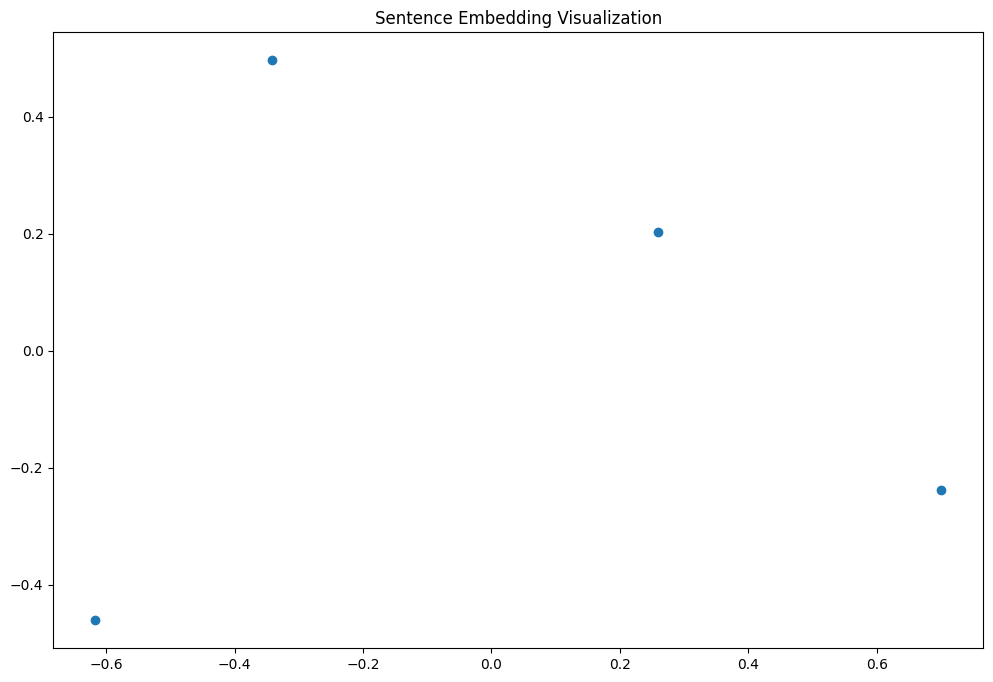

In [23]:
plt.figure(figsize=(12,8))

plt.scatter(
    reduced_embeddings[:,0],
    reduced_embeddings[:,1]
)

plt.title(
    "Sentence Embedding Visualization"
)

plt.show()

### Add Sentence Labels

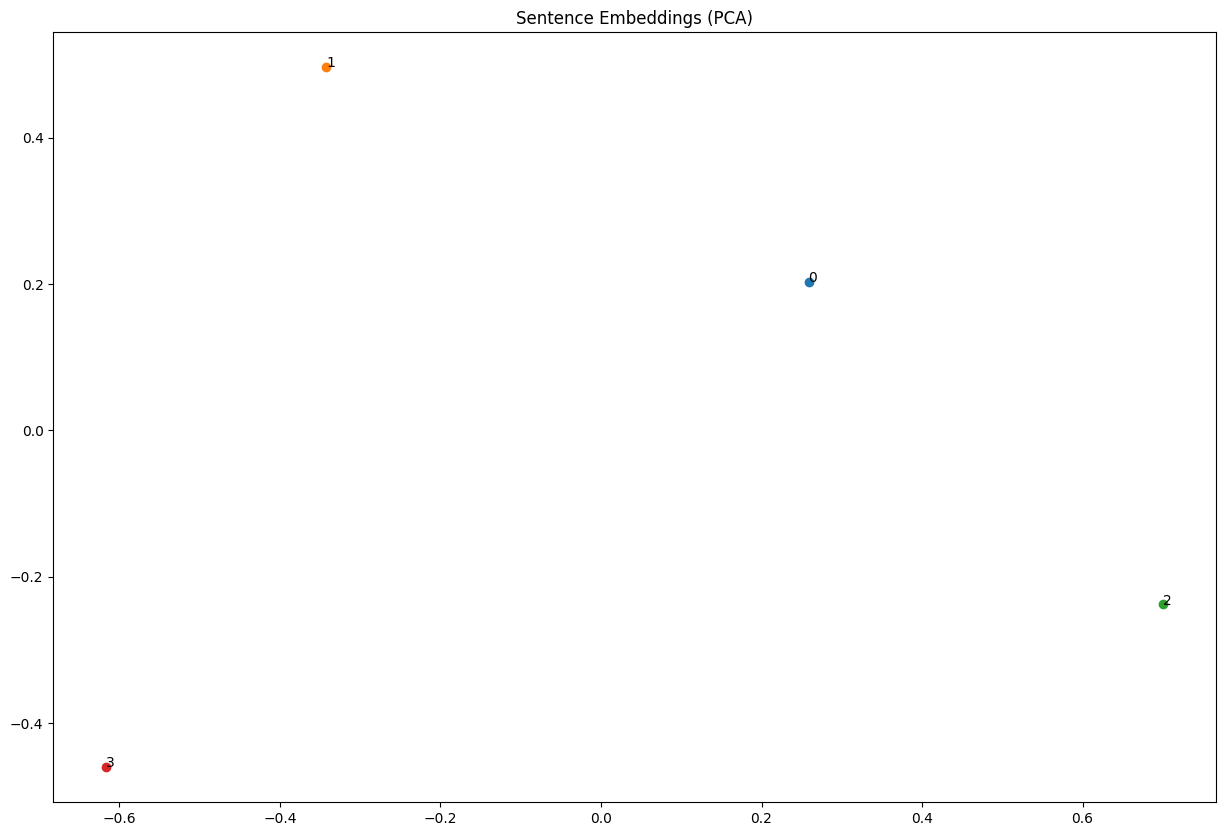

In [24]:
plt.figure(figsize=(15,10))

for i, sentence in enumerate(sentences):

    plt.scatter(
        reduced_embeddings[i,0],
        reduced_embeddings[i,1]
    )

    plt.annotate(
        str(i),
        (
            reduced_embeddings[i,0],
            reduced_embeddings[i,1]
        )
    )

plt.title(
    "Sentence Embeddings (PCA)"
)

plt.show()

In [25]:
with open(
    "../data/raw/sample_text.txt",
    "r",
    encoding="utf-8"
) as file:

    sentences = [
        line.strip()
        for line in file.readlines()
        if line.strip()
    ]

print("Total Sentences:", len(sentences))

Total Sentences: 100


In [26]:
print(embeddings.shape)

(4, 384)


### Create Retrieve Function

In [27]:
def retrieve(query, k=5):

    query_vector = model.encode([query])

    query_vector = np.array(
        query_vector,
        dtype=np.float32
    )

    distances, indices = index.search(
        query_vector,
        k
    )

    results = []

    for idx in indices[0]:
        results.append(sentences[idx])

    return results

In [28]:
retrieve("artificial intelligence")

NameError: name 'index' is not defined